# 01 — Exploratory Data Analysis (Task 1: Sentiment + Spam)

**Goal.** Understand the data before any modelling. Specifically:

1. Confirm shapes, columns, label encoding, missingness.
2. Check label balance in train / val.
3. Read 10 random positives and 10 random negatives — *by eye*, look for spam mixed into both classes (the brief tells us it is there evenly).
4. Look at document-length distribution.
5. Top-50 most-frequent words per declared class, vocabulary size.
6. Form an early hypothesis about what spam *looks like* (URLs? currency symbols? `Subject:`? "click here"?). This informs design choices in `02_baseline_wordlist`, `03_spam_handling`, and `04_models`.

Nothing is saved to disk from this notebook. Output is **understanding**, captured as notes-to-self at the bottom.

Lecture references touched here: W02_L03 (tokenisation, normalisation), W02_L04 (bag-of-words, word-list classifiers, evaluation framing).

In [1]:
import re
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_DIR = Path('../data')
TRAIN_CSV = DATA_DIR / 'sentiment_analysis_training_data.csv'
VAL_CSV   = DATA_DIR / 'sentiment_analysis_validation_data.csv'
TEST_CSV  = DATA_DIR / 'sentiment_analysis_test_data.csv'

assert TRAIN_CSV.exists(), TRAIN_CSV
assert VAL_CSV.exists(), VAL_CSV
assert TEST_CSV.exists(), TEST_CSV

## 1. Load and check shapes / columns / dtypes

In [2]:
train = pd.read_csv(TRAIN_CSV)
val   = pd.read_csv(VAL_CSV)
test  = pd.read_csv(TEST_CSV)

print('train:', train.shape, '| columns:', list(train.columns))
print('val:  ', val.shape,   '| columns:', list(val.columns))
print('test: ', test.shape,  '| columns:', list(test.columns))
print()
print('train dtypes:')
print(train.dtypes)
print()
print('train missing per column:')
print(train.isna().sum())

train: (11503, 2) | columns: ['text', 'label']
val:   (1397, 2) | columns: ['text', 'label']
test:  (1434, 1) | columns: ['text']

train dtypes:
text     object
label     int64
dtype: object

train missing per column:
text     0
label    0
dtype: int64


In [3]:
train.head(3)

,text,label
0,Subject: 98 - 6736 & 98 - 9638 for 1997 ( ua 4...,0
1,nearly every attempt at humor here is doa .,0
2,Subject: tenaska iv 11 / 00\r\ni am having tro...,0


## 2. Label balance

Reminder from the brief: training labels are noisy because spam is mixed evenly into both classes — a `label==1` document is *either* a positive review *or* a spam document mislabelled positive (similarly for `0`). Validation labels we'll trust as a teaching signal but should still check.

In [3]:
print('train label counts:')
print(train['label'].value_counts(dropna=False))
print('train label proportions:')
print(train['label'].value_counts(normalize=True))
print()
print('val label counts:')
print(val['label'].value_counts(dropna=False))
print('val label proportions:')
print(val['label'].value_counts(normalize=True))

train label counts:
label
1    5767
0    5736
Name: count, dtype: int64
train label proportions:
label
1    0.501347
0    0.498653
Name: proportion, dtype: float64

val label counts:
label
1    704
0    693
Name: count, dtype: int64
val label proportions:
label
1    0.503937
0    0.496063
Name: proportion, dtype: float64


## 3. Read 10 random positives and 10 random negatives

This is the most important cell in the notebook. **Read them.** As you read, ask:

- Is this a movie review or is it spam?
- If spam: what gives it away? `Subject:` header? URLs? Money / currency? Generic marketing language?
- Are spam emails differently structured in the two classes, or do they look the same regardless of label?

In [4]:
def show_samples(df, label, n=10, max_chars=600, seed=SEED):
    pool = df[df['label'] == label].sample(n=n, random_state=seed)
    for i, (_, row) in enumerate(pool.iterrows(), 1):
        text = str(row['text'])
        snippet = text if len(text) <= max_chars else text[:max_chars] + ' ... [truncated]'
        print(f'--- label={label} | sample {i}/{n} | len={len(text)} chars ---')
        print(snippet)
        print()

In [5]:
show_samples(train, label=1, n=10)

--- label=1 | sample 1/10 | len=246 chars ---
jirí hubac's script is a gem . his characters are engaging , intimate and the dialogue is realistic and greatly moving . the scope of the silberstein family is large and we grow attached to their lives , full of strength , warmth and vitality . .

--- label=1 | sample 2/10 | len=167 chars ---
maybe it's just because this past year has seen the release of some of the worst film comedies in decades . . . but honestly , analyze that really isn't all that bad .

--- label=1 | sample 3/10 | len=670 chars ---
Subject: customer meeting invitation
good afternoon all ! !
i have attached the invitation to our 8 th annual enron customer meeting to
be held at the don ce sar in st . pete ' s beach , fl .
please feel free to fax or email to your customers as you see necessary ,
but please use the rsvp forms for the trip they will be
attending ( july or august ) . the ' invitation ' attachement is generic and
should be used for both rsvp forms .
the origi

In [6]:
show_samples(train, label=0, n=10)

--- label=0 | sample 1/10 | len=104 chars ---
an excruciating demonstration of the unsalvageability of a movie saddled with an amateurish screenplay .

--- label=0 | sample 2/10 | len=54 chars ---
what's next ? the porky's revenge : ultimate edition ?

--- label=0 | sample 3/10 | len=168 chars ---
chaotic , self-indulgent and remarkably ugly to look at , it's . . . like a series of pretentiously awful student films strung together into one feature-length horror .

--- label=0 | sample 4/10 | len=137 chars ---
Subject: invitation to dinner
music can be started by clicking on the sound icon .
to stop music , right click and end show : ) heather

--- label=0 | sample 5/10 | len=185 chars ---
pretension , in its own way , is a form of bravery . for this reason and this reason only -- the power of its own steadfast , hoity-toity convictions -- chelsea walls deserves a medal .

--- label=0 | sample 6/10 | len=134 chars ---
hey everybody , wanna watch a movie in which a guy dressed as a child

## 4. Document length distributions

Spam emails (especially Enron-style) are often noticeably longer or shorter than a typical movie review, so a length histogram is the cheapest first signal that two distributions are mixed inside each class.

In [7]:
TOKEN_RE = re.compile(r"[a-zA-Z']+")

def tokenize(text):
    return TOKEN_RE.findall(str(text).lower())

train_tokens = train['text'].map(tokenize)
train_lens = train_tokens.map(len)
train['n_tokens'] = train_lens

print(train.groupby('label')['n_tokens'].describe())

        count       mean         std  min   25%   50%   75%     max
label                                                              
0      5736.0  51.455893  113.097537  1.0  14.0  21.0  32.0  1801.0
1      5767.0  49.684932  126.329758  1.0  14.0  21.0  32.0  5394.0


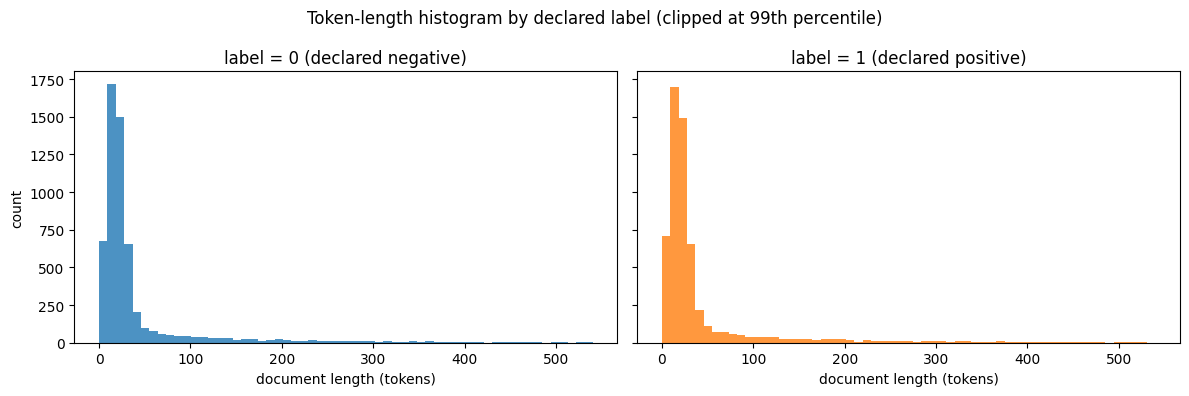

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
bins = np.linspace(0, np.percentile(train_lens, 99), 60)
ax[0].hist(train.loc[train.label == 0, 'n_tokens'], bins=bins, alpha=0.8)
ax[0].set_title('label = 0 (declared negative)')
ax[0].set_xlabel('document length (tokens)')
ax[0].set_ylabel('count')
ax[1].hist(train.loc[train.label == 1, 'n_tokens'], bins=bins, alpha=0.8, color='C1')
ax[1].set_title('label = 1 (declared positive)')
ax[1].set_xlabel('document length (tokens)')
fig.suptitle('Token-length histogram by declared label (clipped at 99th percentile)')
plt.tight_layout()
plt.show()

If the histograms look bimodal — a sharp short-document hump and a broader review hump (or vice-versa) — that's the spam population separating from the review population purely by length.

## 5. Top-50 most-frequent words per declared class

Quick BoW frequency, with NLTK English stopwords removed so the signal isn't drowned by `the / and / of`. We *don't* commit to this preprocessing for modelling — that's `02_*`'s job — we just want a peek.

In [10]:
import nltk
from nltk.corpus import stopwords

try:
    STOP = set(stopwords.words('english'))
except LookupError:
    nltk.download('stopwords', quiet=True)
    STOP = set(stopwords.words('english'))

def top_k_words(token_lists, k=50, drop_stop=True, min_len=2):
    c = Counter()
    for toks in token_lists:
        for t in toks:
            if drop_stop and t in STOP:
                continue
            if len(t) < min_len:
                continue
            c[t] += 1
    return c.most_common(k)

top_pos = top_k_words(train_tokens[train.label == 1], k=50)
top_neg = top_k_words(train_tokens[train.label == 0], k=50)

comparison = pd.DataFrame({
    'pos_word': [w for w, _ in top_pos],
    'pos_count': [c for _, c in top_pos],
    'neg_word': [w for w, _ in top_neg],
    'neg_count': [c for _, c in top_neg],
})
comparison

,pos_word,pos_count,neg_word,neg_count
0,ect,5311,ect,6007
1,hou,2778,hou,3144
2,subject,2625,enron,2888
3,enron,2444,subject,2666
4,com,1460,gas,1340
5,deal,1142,please,1186
6,please,1055,deal,1178
7,gas,1033,cc,995
8,meter,980,pm,986
9,cc,953,com,984


Words that look out-of-place for movie reviews (`subject`, `enron`, `http`, `email`, `company`, `money`, currency tokens, dates) are spam tells. They should appear in *both* class lists if spam is evenly distributed.

### Words with the biggest frequency *difference* between classes (W02_L04)

The lecture (W02_L04) names this as one way to build word-list classifiers. Here it's a sanity check: if the corpus were clean reviews, this list would be sentiment-loaded (`great / boring / wonderful / waste`). If it's polluted with spam, we may also see spam-vocabulary leaking in.

In [ ]:
from collections import Counter

def class_freq(token_lists):
    c = Counter()
    for toks in token_lists:
        c.update(toks)
    return c

freq_pos = class_freq(train_tokens[train.label == 1])
freq_neg = class_freq(train_tokens[train.label == 0])
n_pos = sum(freq_pos.values())
n_neg = sum(freq_neg.values())

vocab_all = set(freq_pos) | set(freq_neg)
rows = []
for w in vocab_all:
    if w in STOP or len(w) < 3:
        continue
    p = freq_pos[w] / n_pos
    n = freq_neg[w] / n_neg
    total = freq_pos[w] + freq_neg[w]
    if total < 50:  # ignore rare words
        continue
    rows.append((w, p - n, freq_pos[w], freq_neg[w], total))
diff_df = pd.DataFrame(rows, columns=['word', 'pos_minus_neg_rate', 'pos_count', 'neg_count', 'total'])

print('Top 25 words skewed toward POSITIVE class:')
print(diff_df.sort_values('pos_minus_neg_rate', ascending=False).head(25).to_string(index=False))
print()
print('Top 25 words skewed toward NEGATIVE class:')
print(diff_df.sort_values('pos_minus_neg_rate', ascending=True).head(25).to_string(index=False))

Top 25 words skewed toward POSITIVE class:
        word  pos_minus_neg_rate  pos_count  neg_count  total
         com            0.001762       1460        984   2444
         net            0.000756        303         89    392
        film            0.000492        637        511   1148
         aol            0.000363        172         70    242
       vance            0.000311        224        139    363
performances            0.000290        117         35    152
        look            0.000276        210        135    345
         xls            0.000270        423        356    779
     volumes            0.000257        360        295    655
        best            0.000255        176        106    282
     october            0.000231        174        111    285
       still            0.000223        198        138    336
       great            0.000222        150         89    239
        life            0.000221        145         84    229
        love            0.0

## 6. Vocabulary size & coverage

In [13]:
all_freq = freq_pos + freq_neg
V = len(all_freq)
print(f'Raw vocabulary size (lowercased a-z tokens): {V}')
for cutoff in [1, 2, 5, 10, 50]:
    kept = sum(1 for c in all_freq.values() if c >= cutoff)
    print(f'  >= {cutoff} occurrences: {kept} types ({kept / V:.1%})')

total_tokens = sum(all_freq.values())
print(f'Total tokens in train: {total_tokens:,}')
print(f'Type/token ratio: {V / total_tokens:.4f}')

Raw vocabulary size (lowercased a-z tokens): 27066
  >= 1 occurrences: 27066 types (100.0%)
  >= 2 occurrences: 14914 types (55.1%)
  >= 5 occurrences: 7744 types (28.6%)
  >= 10 occurrences: 4722 types (17.4%)
  >= 50 occurrences: 1359 types (5.0%)
Total tokens in train: 581,684
Type/token ratio: 0.0465


## 7. Spam tells — quick targeted searches

Without committing to a spam classifier yet, count how often candidate spam markers appear, *broken down by declared label*. If they appear at similar rates in both classes, that's consistent with the brief's claim that spam is mixed evenly.

In [14]:
MARKERS = {
    'has_subject_header': r'(?im)^\s*subject\s*:',
    'has_url':            r'https?://|www\.',
    'has_email_addr':     r'[\w.\-]+@[\w.\-]+',
    'has_currency':       r'[\$\xa3\u20ac]\s*\d|\busd\b|\bdollars?\b',
    'has_click_here':     r'\bclick\s+here\b',
    'has_unsubscribe':    r'\bunsubscribe\b',
    'has_enron':          r'\benron\b',
    'has_phone_like':     r'\b\d{3}[\s\-.]\d{3}[\s\-.]\d{4}\b',
    'mentions_movie':     r'\b(film|movie|cinema|director|actor|actress|scene|plot|character)\b',
}

marker_df = pd.DataFrame({
    name: train['text'].astype(str).str.contains(pat, regex=True, case=False, na=False)
    for name, pat in MARKERS.items()
})
marker_df['label'] = train['label'].values
rates = marker_df.groupby('label').mean().T
rates.columns = [f'label={c}' for c in rates.columns]
rates['overall'] = marker_df.drop(columns='label').mean()
rates.style.format('{:.1%}')

/var/folders/xk/j3sj9c6j70jcsyq_ffk0shw40000gn/T/ipykernel_13183/2052633731.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  name: train['text'].astype(str).str.contains(pat, regex=True, case=False, na=False)


,label=0,label=1,overall
has_subject_header,25.6%,26.0%,25.8%
has_url,0.0%,0.0%,0.0%
has_email_addr,0.0%,0.0%,0.0%
has_currency,2.9%,2.5%,2.7%
has_click_here,0.2%,0.2%,0.2%
has_unsubscribe,0.3%,0.3%,0.3%
has_enron,10.3%,10.3%,10.3%
has_phone_like,0.1%,0.0%,0.1%
mentions_movie,24.5%,23.2%,23.8%


Read this table carefully:
- The spam markers (`has_subject_header`, `has_url`, `has_enron`, `has_unsubscribe`, …) should appear at **roughly equal rates in both classes** if the brief's "evenly mixed" claim holds.
- The review marker (`mentions_movie`) should appear at **lower** rate than 100% — the gap is roughly the spam contamination fraction.

## 8. Side-by-side: a couple of likely-spam vs likely-review samples

Quick visual confirmation that the markers above identify what we think they identify. *Not* a classifier — just sanity.

In [15]:
looks_like_spam = train['text'].astype(str).str.contains(
    r'(?im)^\s*subject\s*:|\benron\b|\bunsubscribe\b', regex=True, na=False
)
looks_like_review = train['text'].astype(str).str.contains(
    r'\b(film|movie|director|plot)\b', regex=True, case=False, na=False
) & ~looks_like_spam

print('Looks-like-spam rate by declared label:')
print(looks_like_spam.groupby(train['label']).mean())
print()
print('Looks-like-review rate by declared label:')
print(looks_like_review.groupby(train['label']).mean())

Looks-like-spam rate by declared label:
label
0    0.256625
1    0.260447
Name: text, dtype: float64

Looks-like-review rate by declared label:
label
0    0.227859
1    0.209988
Name: text, dtype: float64


/var/folders/xk/j3sj9c6j70jcsyq_ffk0shw40000gn/T/ipykernel_13183/1917903493.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  looks_like_review = train['text'].astype(str).str.contains(


In [16]:
print('=== Two likely-spam docs sitting under label=1 ===')
show_samples(train[looks_like_spam & (train.label == 1)].assign(label=1), label=1, n=2, seed=1)
print('=== Two likely-spam docs sitting under label=0 ===')
show_samples(train[looks_like_spam & (train.label == 0)].assign(label=0), label=0, n=2, seed=1)
print('=== Two likely-review docs under label=1 ===')
show_samples(train[looks_like_review & (train.label == 1)].assign(label=1), label=1, n=2, seed=1)
print('=== Two likely-review docs under label=0 ===')
show_samples(train[looks_like_review & (train.label == 0)].assign(label=0), label=0, n=2, seed=1)

=== Two likely-spam docs sitting under label=1 ===
--- label=1 | sample 1/2 | len=1293 chars ---
Subject: may 2001 nomination
bob ,
questions based on the information in the facilitation by location report :
1 . meter 9643 hgpl / hpl - stratton , tejones operating corporation , sitara 266970 : should this purchase be at meter 9638 , freeman prod - maxine field in trade zone 18 ?
2 . i presume we are not counting both meter 9848 north padre island blk 8 and meter 9862 lehman / spinnaker onshore . isn ' t this the same gas ?
3 . meter 3536 seahawk / a - s ( mat plt 520 ) , eog resources , sitara 725391 : is this purchase properly in the wellhead book ?
4 . meter 6884 pgtt junction 16  ... [truncated]

--- label=1 | sample 2/2 | len=99 chars ---
Subject: hpl nom for november 28 , 2000
( see attached file : hplnl 128 . xls )
- hplnl 128 . xls

=== Two likely-spam docs sitting under label=0 ===
--- label=0 | sample 1/2 | len=598 chars ---
Subject: deal tickets
daren i have three meters that

## 9. Notes-to-self (filled in from executed outputs)

Concrete observations from this run, used as input for `02_baseline.ipynb`, `03_spam_handling`, `04_models`.

**Shapes / integrity.** Train = 11,503 rows, val = 1,397 rows, test = 1,434 rows. Columns `text, label` on train/val; test is `text` only. No missing values in any column. Train labels are integer-coded `{0, 1}`; test has no label column.

**Class balance.** Train: 5,767 positives / 5,736 negatives (50.13 % / 49.87 %). Val: 704 / 693 (50.39 % / 49.61 %). Effectively balanced — no class-weighting needed for the baseline.

**What spam looks like in this corpus.** Enron-style business email: `Subject:` header, internal-routing tokens (`ect`, `hou`, `pec`, `ena`, `hpl`), business/finance vocabulary (`deal`, `meter`, `gas`, `mmbtu`, `volumes`, `nom`, `sitara`), people-names (`daren`, `farmer`, `robert`, `vance`, `lisa`), forwarded-mail boilerplate (`forwarded`, `cc`, `attached`), and `.xls` attachments. Vocabulary is *visually disjoint* from movie-review language.

**Spam-marker rate per class** (regex `^subject:|enron|unsubscribe`). Label 0: **25.66 %**. Label 1: **26.04 %**. Essentially identical → confirms the brief's claim that spam is mixed *evenly* into both declared classes. Implication: a sentiment-only classifier trained on raw labels cannot resolve the spam subset and will learn business-email vocabulary as a sentiment cue. This is the §3.1 motivation in the project plan.

**Review-marker rate per class.** Label 0: 22.79 %. Label 1: 21.00 %. Also near-symmetric, as expected.

**Length distribution.** Per-class summary stats are nearly identical at the median (≈ 21 tokens both classes) but the upper tail is wildly different: max length is 1,801 tokens for label 0 and 5,394 tokens for label 1. The histograms (cell 13) show a short hump around 10–30 tokens (the real reviews) and a long, heavy tail (the Enron emails). Length alone won't cleanly separate the populations because a minority of real reviews are long and some emails are short, but `n_tokens` is a useful **auxiliary feature** for the spam detector in `03_*`.

**Top-50 per class is dominated by spam vocabulary.** Both class top-50 lists are headed by `ect, hou, subject, enron, com, deal, please, gas, meter, cc, pm, hpl, daren, thanks, …`. Movie-review words (`film`, `movie`, `know`, `see`, `like`, `time`, …) appear *below* the email vocabulary in both lists. Direct visual confirmation that BoW on the raw labels learns spam, not sentiment.

**Class-difference list (W02_L04).** Even the most-positive-skewed words contain spam terms (`com, net, aol, xls, volumes, october, vance, taylor, lisa`) mixed with genuine sentiment carriers (`film, performances, best, great, love, funny, fun, heart, family`). Most-negative-skewed contains real signal (`bad`, `like`, `movie`) alongside more business tokens (`ect, enron, hou, gas, pec, ena, corp, price, order`). A word-list classifier built from raw frequency differences will therefore inherit spam vocabulary as fake sentiment carriers — another argument for spam-stage-first.

**Vocabulary.** Raw lowercased `[a-zA-Z']+` vocabulary = **27,066** types over 581,684 tokens; type/token ratio 0.0465. Coverage: `min_df ≥ 2` keeps 14,914 (55.1 %), `min_df ≥ 5` keeps 7,744 (28.6 %). **Decision:** use `min_df=2` in the baseline TF-IDF (already done in `02_baseline.ipynb`); revisit `min_df=5` if memory/time is an issue or to denoise the spam-handling stage.

**Stopwords / negation (tripwire).** NLTK English stopwords list contains `not, no, never, nor, none, nothing, neither, nobody, nowhere`. These are sentiment-polarity reversers (W02_L03). The `preprocess` module subtracts them from the default stopword set via `NEGATION_WORDS`. **Never** remove them.

**Test-set ordering tripwire.** Brief warns twice: do **not** reorder the test set. Any pipeline that touches `sentiment_analysis_test_data.csv` must preserve row order end-to-end (load → preprocess → vectorise → predict → write).

---

### Plan inputs for downstream notebooks

**`02_baseline.ipynb` (DONE — see file).** TF-IDF + LR on raw labels, no spam handling. Confirmed contamination: val accuracy **0.6951** overall, but **0.5106 on the spam-like subset** vs **0.7523 on review-like docs**. The 25-point gap is the empirical exhibit for report §1.1.

**`03_spam_handling` (next).** Three lecture-compatible approaches:
- *A — TF-IDF + cosine-to-centroid:* build positive-review and negative-review centroids on suspected-clean docs (`~looks_like_spam`); flag any doc whose max cosine to either centroid falls below threshold τ as spam → label −1. PR-tradeoff sweep over τ as per W03_L05.
- *B — word-list filter:* `L_M = L+ ∪ L−` from the class-difference cell; flag docs whose spam-vocabulary overlap exceeds threshold.
- *C — Multinomial NB max-posterior threshold:* train NB on 3 self-labelled classes using the regex marker as weak supervision for the spam class; emit −1 when `max p(class | doc) < τ`.
Evaluation: since val labels are 2-class only, measure (a) self-consistency against the regex marker and (b) downstream impact on sentiment-stage accuracy on `~spam` val docs.

**`04_models` (sentiment stage, post-filter).** Required classifiers from the lectures: word-list (W02_L04), Multinomial NB (W03_L05), Logistic Regression (W03_L05). Feature reps to compare: BoW counts, BoW binary, TF-IDF, averaged Word2Vec (W05_L09). Compare stemming vs lemmatisation per §3.2 of the revised plan using `porter_stem` already exposed by `preprocess.py`.

**Reporting (W02_L04 extended).** Once the spam stage is wired in, switch from 2×2 to **3×3 confusion matrix** including the −1 dummy label. Do not mix the dummy label into 2-class precision/recall numbers.